In [12]:
# =====================================================
# SETUP
# =====================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import kruskal

import plotly.express as px

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["font.size"] = 11

In [13]:
# =====================================================
# FETCH DATA
# =====================================================

URL = "https://ourworldindata.org/grapher/press-freedom-index-rsf.csv?v=1&csvType=full&useColumnShortNames=false"

df = pd.read_csv(URL)

print(f"Rows: {len(df):,}")
print(f"Countries: {df['Entity'].nunique()}")
print(f"Years: {df['Year'].min()} - {df['Year'].max()}")

Rows: 1,619
Countries: 181
Years: 2013 - 2021


In [14]:
# =====================================================
# CLEAN DATA
# =====================================================

df = df.rename(
    columns={
        "Entity":"Country",
        "Press Freedom Index":"Score"
    }
)

df = df[["Country","Code","Year","Score"]]

df["Score"] = pd.to_numeric(
    df["Score"],
    errors="coerce"
)

df = df.dropna()

df.head()

,Country,Code,Year,Score
0,Afghanistan,AFG,2013,37.36
1,Afghanistan,AFG,2014,37.07
2,Afghanistan,AFG,2015,37.44
3,Afghanistan,AFG,2016,37.75
4,Afghanistan,AFG,2017,39.46


In [15]:
print(df.isnull().sum())

Country    0
Code       0
Year       0
Score      0
dtype: int64


In [16]:
coverage = (
    df.groupby("Country")
      .agg(
          Years=("Year","count")
      )
)

coverage.describe()

,Years
count,179.000000
mean,8.988827
std,0.105406
min,8.000000
25%,9.000000
50%,9.000000
75%,9.000000
max,9.000000


In [17]:
expected_years = set(df["Year"].unique())

incomplete = []

for country, group in df.groupby("Country"):

    years = set(group["Year"])

    if years != expected_years:
        incomplete.append(country)

print(
    f"Incomplete countries: {len(incomplete)}"
)

Incomplete countries: 2


In [18]:
coverage[coverage["Years"] < coverage["Years"].max()]

,Years
Country,
Belize,8
Eswatini,8


In [19]:
df["Score"].describe()

count    1609.000000
mean       34.293860
std        16.317823
min         6.380000
25%        24.120000
50%        30.760000
75%        42.640000
max        88.870000
Name: Score, dtype: float64

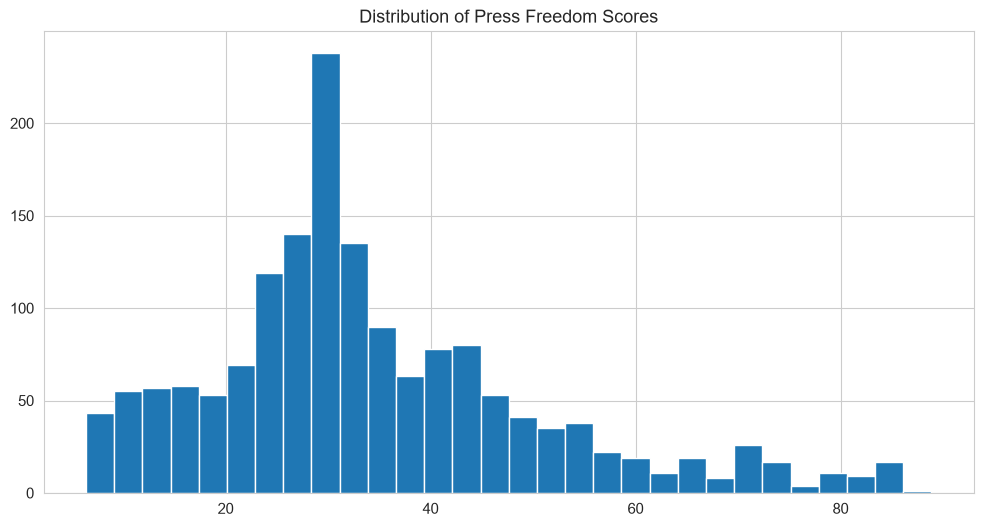

In [20]:
plt.hist(
    df["Score"],
    bins=30
)

plt.title(
    "Distribution of Press Freedom Scores"
)

plt.show()

In [21]:
print(
    "Skewness:",
    df["Score"].skew()
)

print(
    "Kurtosis:",
    df["Score"].kurtosis()
)

Skewness: 0.927025799370354
Kurtosis: 0.836251419684118


In [22]:
sample = df["Score"].sample(
    min(len(df),5000),
    random_state=42
)

stat,p = stats.shapiro(sample)

print(
    f"Statistic={stat:.4f}"
)

print(
    f"P-value={p:.4e}"
)

Statistic=0.9391
P-value=3.5884e-25


H0: Data follows normal distribution.

If p < 0.05:
Reject H0.

In [23]:
import country_converter as coco

df["Region"] = coco.convert(
    names=df["Country"],
    to="UNregion"
)

df["Region"].value_counts()

Region
Western Asia                 171
Eastern Africa               162
Western Africa               144
Southern Europe              126
South America                108
South-eastern Asia            99
Eastern Europe                90
Northern Europe               90
Southern Asia                 81
Middle Africa                 72
Western Europe                72
Central America               71
Eastern Asia                  63
Northern Africa               54
Caribbean                     45
Central Asia                  45
Southern Africa               44
Australia and New Zealand     18
Northern America              18
Melanesia                     18
Polynesia                     18
Name: count, dtype: int64

In [24]:
latest_year = df["Year"].max()

latest = df[
    df["Year"] == latest_year
]

In [25]:
regional_stats = (
    latest
    .groupby("Region")["Score"]
    .agg(
        ["count",
         "mean",
         "median",
         "std",
         "min",
         "max"]
    )
    .sort_values("mean")
)

regional_stats

,count,mean,median,std,min,max
Region,,,,,,
Northern Europe,10,13.305000,13.580,5.806093,6.72,21.59
Australia and New Zealand,2,14.915000,14.915,6.894291,10.04,19.79
Western Europe,8,15.392500,15.790,4.539697,9.67,22.60
Northern America,2,19.590000,19.590,6.137687,15.25,23.93
Polynesia,2,21.915000,21.915,3.783021,19.24,24.59
Melanesia,2,26.400000,26.400,2.149605,24.88,27.92
Southern Europe,14,26.790000,28.675,6.281424,10.11,34.33
Southern Africa,5,28.502000,23.250,10.958292,19.72,46.34
Western Africa,16,30.135000,30.185,5.616407,20.09,39.69


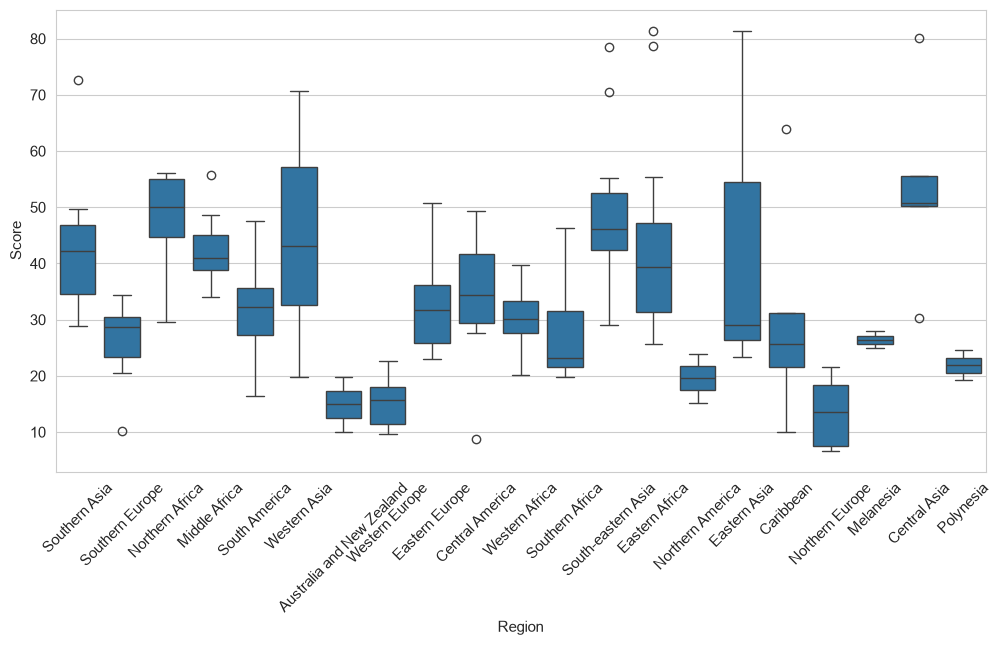

In [26]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=latest,
    x="Region",
    y="Score"
)

plt.xticks(rotation=45)

plt.show()

In [27]:
groups = [
    g["Score"].values
    for _,g in latest.groupby("Region")
]

H,p = kruskal(*groups)

print(H)
print(p)

95.58029598531049
7.71721313548326e-12


In [28]:
n = len(latest)

k = latest["Region"].nunique()

epsilon_sq = (
    H - k + 1
) / (
    n - k
)

print(
    f"Epsilon² = {epsilon_sq:.3f}"
)

Epsilon² = 0.478


In [29]:
annual = (
    df.groupby("Year")
      ["Score"]
      .mean()
      .reset_index()
)

annual

,Year,Score
0,2013,32.406497
1,2014,32.877486
2,2015,33.530056
3,2016,34.723966
4,2017,35.150670
5,2018,34.861899
6,2019,35.068045
7,2020,34.861285
8,2021,35.143743


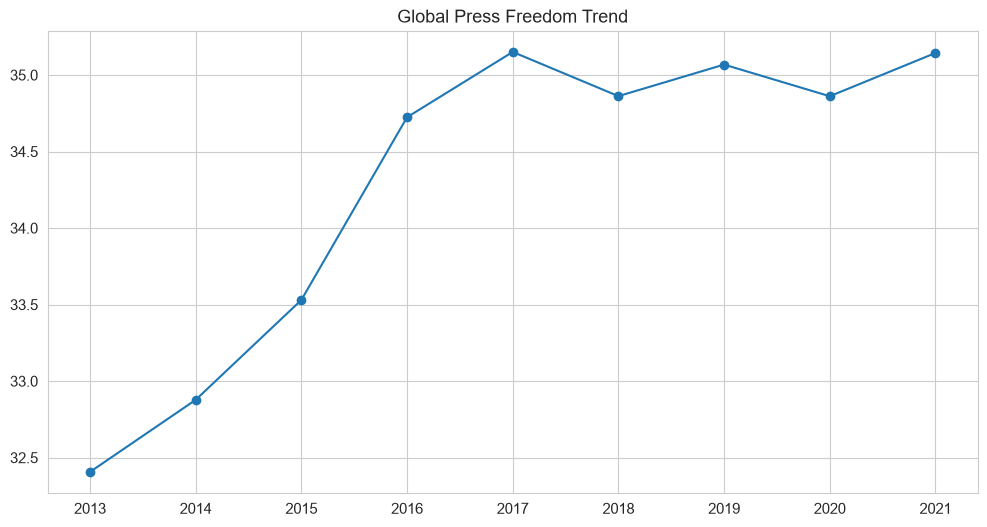

In [30]:
plt.plot(
    annual["Year"],
    annual["Score"],
    marker="o"
)

plt.title(
    "Global Press Freedom Trend"
)

plt.show()

In [31]:
change = (
    annual.iloc[-1]["Score"]
    -
    annual.iloc[0]["Score"]
)

print(change)

2.737245841618538


In [32]:
pct_change = (
    annual.iloc[-1]["Score"]
    -
    annual.iloc[0]["Score"]
) / annual.iloc[0]["Score"] * 100

In [33]:
first = df["Year"].min()
last = df["Year"].max()

pivot = (
    df.pivot(
        index="Country",
        columns="Year",
        values="Score"
    )
)

pivot["Change"] = (
    pivot[last]
    -
    pivot[first]
)

pivot.sort_values(
    "Change"
).head(10)

Year,2013,2014,2015,2016,2017,2018,2019,2020,2021,Change
Country,,,,,,,,,,
Somalia,73.59,73.19,72.31,65.35,65.95,63.04,57.24,55.45,55.47,-18.12
Sudan,70.06,71.88,72.34,72.53,73.56,71.13,72.45,55.33,52.93,-17.13
Sri Lanka,56.59,59.13,60.28,44.96,44.34,41.37,39.61,41.94,42.20,-14.39
Gambia,45.09,46.42,44.50,46.53,46.70,38.36,31.35,30.62,30.76,-14.33
Equatorial Guinea,67.20,67.95,66.23,66.47,66.47,66.47,58.35,56.38,55.67,-11.53
Tunisia,39.93,38.69,38.68,31.60,32.22,30.91,29.61,29.45,29.53,-10.40
Uzbekistan,60.39,61.01,61.14,61.15,66.11,60.84,53.52,53.07,50.74,-9.65
Syria,78.53,77.04,77.29,81.35,81.49,79.22,71.78,72.57,70.63,-7.90
Cuba,71.64,70.92,70.21,70.23,71.75,68.90,63.81,63.81,63.94,-7.70


In [34]:
pivot.sort_values(
    "Change",
    ascending=False
).head(10)

Year,2013,2014,2015,2016,2017,2018,2019,2020,2021,Change
Country,,,,,,,,,,
Tajikistan,35.71,34.86,36.19,50.34,50.27,50.06,54.02,55.34,55.52,19.81
Libya,37.86,39.84,45.99,57.89,56.81,56.79,55.77,55.77,55.73,17.87
Andorra,6.82,6.82,19.87,19.87,21.03,22.21,24.63,23.23,23.32,16.50
Poland,13.11,11.03,12.71,23.89,26.47,26.59,28.89,28.65,28.84,15.73
Central African Republic,26.61,33.13,33.84,33.60,36.12,35.25,47.27,42.87,41.92,15.31
Brunei,35.45,35.45,36.76,53.85,53.72,51.48,51.48,49.65,49.91,14.46
Tanzania,27.34,27.30,28.09,28.65,30.65,30.65,36.28,40.25,40.69,13.35
Czechia,10.17,10.07,11.62,16.66,16.91,21.89,24.89,23.57,23.38,13.21
Venezuela,34.44,35.37,40.61,44.77,42.94,46.03,49.10,45.66,47.60,13.16


In [35]:
volatility = (
    df.groupby("Country")
      ["Score"]
      .std()
      .sort_values(
          ascending=False
      )
)

volatility.describe()

count    179.000000
mean       2.633891
std        1.787262
min        0.469787
25%        1.377359
50%        2.095074
75%        3.288939
max        8.762744
Name: Score, dtype: float64

In [36]:
top_volatile = volatility.head(10)

In [37]:
volatility.tail(10)

Country
Armenia            0.738914
Kosovo             0.722105
Peru               0.703487
Kyrgyzstan         0.701088
Albania            0.610655
Burkina Faso       0.593790
Uruguay            0.540974
Taiwan             0.538818
Guyana             0.511835
Northern Cyprus    0.469787
Name: Score, dtype: float64

<Axes: xlabel='Country'>

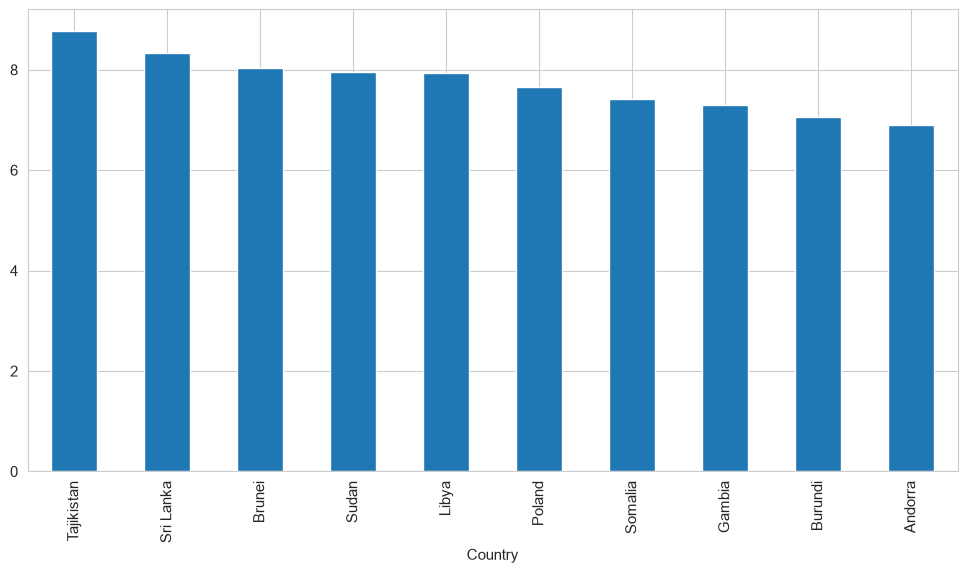

In [38]:
top_volatile.plot.bar()

In [39]:
fig = px.choropleth(
    latest,
    locations="Code",
    color="Score",
    hover_name="Country",
    color_continuous_scale="RdYlGn_r",
    title=f"Press Freedom Index ({latest_year})"
)

fig.show()

In [40]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [41]:
features = pd.DataFrame()

features["MeanScore"] = (
    df.groupby("Country")
      ["Score"]
      .mean()
)

features["Volatility"] = (
    df.groupby("Country")
      ["Score"]
      .std()
)

features["Trend"] = (
    pivot["Change"]
)

features = features.dropna()

In [42]:
scaler = StandardScaler()

X = scaler.fit_transform(
    features
)

In [43]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

features["Cluster"] = (
    kmeans.fit_predict(X)
)

cluster_profile = (
    features.groupby("Cluster")
    .agg({
        "MeanScore":"mean",
        "Volatility":"mean",
        "Trend":"mean"
    })
)

cluster_profile

,MeanScore,Volatility,Trend
Cluster,,,
0,34.981614,2.646261,6.323774
1,61.781208,4.182918,-5.818696
2,39.436167,5.727110,13.009500
3,24.730947,1.401605,0.238395


In [44]:
features.corr(numeric_only=True)

,MeanScore,Volatility,Trend,Cluster
MeanScore,1.000000,0.358221,-0.119322,-0.397987
Volatility,0.358221,1.000000,0.225465,-0.331308
Trend,-0.119322,0.225465,1.000000,-0.266887
Cluster,-0.397987,-0.331308,-0.266887,1.000000


<Axes: >

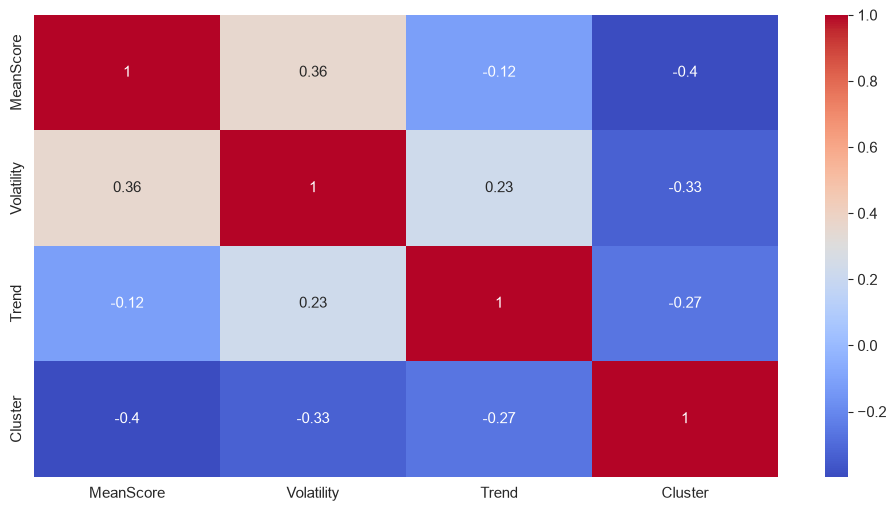

In [45]:
sns.heatmap(
    features.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

## Limitations

- Press Freedom Index is based on RSF methodology and expert assessments.
- Regional classifications are simplified.
- The analysis identifies associations rather than causal relationships.
- Changes in score do not necessarily imply changes in underlying media conditions alone.